## 1. 라이브러리 & 데이터 로딩

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ✅ 파일명 수정 (언더바 사용)
data = pd.read_csv('서울시 강남구 휴게음식점 인허가 정보.csv', encoding='EUC-KR')
print("총 데이터 수:", len(data))
data.head()

총 데이터 수: 4499


,개방자치단체코드,관리번호,인허가일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,전화번호,소재지면적,...,공장판매직종업원수,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지
0,3220000,3220000-104-2023-00499,2023-09-08,1,영업/정상,1,영업,,02-6406-4845,46.53,...,NaN,NaN,NaN,NaN,NaN,N,46.53,NaN,NaN,NaN
1,3220000,3220000-104-2024-00867,2024-12-20,3,폐업,2,폐업,2026-04-09,02-541-9895,68,...,NaN,NaN,NaN,NaN,NaN,N,68.00,NaN,NaN,NaN
2,3220000,3220000-104-2021-00765,2021-12-22,1,영업/정상,1,영업,,02-460-3097,145.62,...,NaN,NaN,NaN,NaN,NaN,N,145.62,NaN,NaN,NaN
3,3220000,3220000-104-2020-00547,2020-10-21,3,폐업,2,폐업,2026-04-09,NaN,24.48,...,NaN,NaN,NaN,NaN,NaN,N,24.48,NaN,NaN,NaN
4,3220000,3220000-104-2024-00473,2024-07-26,1,영업/정상,1,영업,,02-511-1910,159.15,...,NaN,NaN,NaN,NaN,NaN,Y,159.15,NaN,NaN,NaN


## 2. 전처리 & 프랜차이즈 분류

In [30]:
cols = ['사업장명', '상세영업상태명', '인허가일자', '폐업일자', '도로명주소', '좌표정보(X)', '좌표정보(Y)']
data = data[cols].copy()

# 날짜 변환
data['인허가일자'] = pd.to_datetime(data['인허가일자'], errors='coerce')
data['폐업일자']  = pd.to_datetime(data['폐업일자'],  errors='coerce')

# ✅ 프랜차이즈 키워드 수정 (실제 데이터 기준)
franchise_keywords = {
    '스타벅스': '스타벅스',
    '메가커피':  '메가엠지씨',   # ✅ 수정: '메가엠지씨커피' 실제 이름
    '컴포즈':   '컴포즈',
    '빽다방':   '빽다방',
    '투썸':     '투썸플레이스',  # ✅ 수정: '투썸플레이스' 실제 이름
}

def classify(name):
    for brand, keyword in franchise_keywords.items():
        if keyword in str(name):
            return brand
    return '개인카페'

data['브랜드'] = data['사업장명'].apply(classify)

# 브랜드별 수량 확인
print(data['브랜드'].value_counts())

브랜드
개인카페    4269
메가커피      72
스타벅스      70
투썸        46
컴포즈       30
빽다방       12
Name: count, dtype: int64


C:\Users\caleb\AppData\Local\Temp\ipykernel_10672\1907884632.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['폐업일자']  = pd.to_datetime(data['폐업일자'],  errors='coerce')


## 3. 브랜드별 추출

In [31]:
# 스타벅스
starbucks = data[data['브랜드'] == '스타벅스'].copy()
print(f"강남구 스타벅스 총 {len(starbucks)}개")
print(starbucks[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

강남구 스타벅스 총 70개
                 사업장명 상세영업상태명      인허가일자       폐업일자
12         스타벅스 삼성휘문점      영업 2026-04-06        NaT
48     스타벅스커피 강남구청정문점      영업 2017-03-16        NaT
66         스타벅스 강남자곡점      영업 2025-12-23        NaT
90      스타벅스 강남아이퀘스트점      영업 2026-03-17        NaT
117       스타벅스 대치사거리점      영업 2016-05-09        NaT
125    스타벅스 신논현역3번출구점      영업 2026-01-16        NaT
127       스타벅스 호림아트센터      영업 2026-01-23        NaT
129      스타벅스 한티역8번출구      영업 2026-01-20        NaT
167    스타벅스커피 포스코사거리점      영업 2016-02-23        NaT
199      스타벅스커피 강남대로점      영업 2013-06-18        NaT
203        스타벅스 강남우성점      영업 2016-11-08        NaT
221         스타벅스 강남R점      영업 2017-08-14        NaT
346         스타벅스 삼성역점      영업 2022-06-28        NaT
426    스타벅스커피 청담영동대로점      영업 2016-12-21        NaT
444   스타벅스 스타필드코엑스몰R점      영업 2017-05-01        NaT
449    스타벅스 강남파이낸스센터점      영업 2025-07-23        NaT
811     스타벅스 청담역6번출구점      영업 2025-12-01        NaT
938      스타벅스커피 역삼대로점      영업 2013-06-20        N

In [32]:
# 메가커피
mega = data[data['브랜드'] == '메가커피'].copy()
print(f"강남구 메가커피 총 {len(mega)}개")
print(mega[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

강남구 메가커피 총 72개
                    사업장명 상세영업상태명      인허가일자 폐업일자
31          메가엠지씨커피 선릉역점      영업 2025-05-15  NaT
47          메가엠지씨커피 역삼역점      영업 2023-02-07  NaT
75       메가엠지씨커피 선릉세웅타워점      영업 2025-12-15  NaT
76         메가엠지씨커피 봉은사역점      영업 2025-12-15  NaT
78          메가엠지씨커피 한티역점      영업 2019-04-15  NaT
87      메가엠지씨커피 선릉대우아이빌점      영업 2026-02-23  NaT
94       메가엠지씨커피 서울언주초교점      영업 2025-11-21  NaT
144         메가엠지씨커피 청담역점      영업 2026-03-03  NaT
152      메가엠지씨커피 선릉현대타워점      영업 2026-03-13  NaT
153      메가엠지씨커피 신사강남시장점      영업 2026-02-09  NaT
191      메가엠지씨커피영동2교교차로점      영업 2025-10-24  NaT
194         메가엠지씨커피 수서역점      영업 2023-06-09  NaT
229      메가엠지씨커피 포스코사거리점      영업 2025-10-21  NaT
283      메가엠지씨커피 역삼센터필드점      영업 2025-10-14  NaT
332        메가엠지씨커피 선정릉역점      영업 2023-08-28  NaT
333     메가엠지씨커피 역삼e편한세상점      영업 2024-07-10  NaT
395      메가엠지씨커피 일원맛의거리점      영업 2023-03-31  NaT
407       메가엠지씨커피 삼성중앙역점      영업 2022-05-10  NaT
437       메가엠지씨커피 백암아트홀점      영업 2025-03-10  NaT
458  

In [33]:
# 컴포즈
compose = data[data['브랜드'] == '컴포즈'].copy()
print(f"강남구 컴포즈 총 {len(compose)}개")
print(compose[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

강남구 컴포즈 총 30개
                                사업장명 상세영업상태명      인허가일자       폐업일자
0                      컴포즈커피 신사세로수길점      영업 2023-09-08        NaT
118                      컴포즈커피 강남포이점      영업 2024-05-16        NaT
147                     컴포즈커피 대치학원가점      영업 2026-03-05        NaT
299                      컴포즈커피 개포중앙점      영업 2024-06-03        NaT
418                    컴포즈커피 코엑스사거리점      영업 2021-11-22        NaT
686                      컴포즈커피 양재도곡점      영업 2022-09-16        NaT
822                 컴포즈커피 강남역센트럴애비뉴점      폐업 2021-11-17 2025-06-10
862                   컴포즈커피 테헤란아이파크점      영업 2023-05-26        NaT
1149                     컴포즈커피 삼성대치점      영업 2020-09-15        NaT
1201                     컴포즈커피 개포중앙점      폐업 2022-05-24 2024-06-03
1490  컴포즈 커피 개포구룡초교점(COMPOSE COFFEE)      영업 2024-08-02        NaT
1555                     컴포즈커피 강남세곡점      영업 2020-05-18        NaT
1741                             컴포즈      폐업 2020-11-09 2024-07-12
2111                  컴포즈커피 서울세관사거리점      영업 202

In [34]:
# 빽다방
baek = data[data['브랜드'] == '빽다방'].copy()
print(f"강남구 빽다방 총 {len(baek)}개")
print(baek[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

강남구 빽다방 총 12개
             사업장명 상세영업상태명      인허가일자       폐업일자
34            빽다방      영업 2015-10-01        NaT
610      빽다방 신사역점      폐업 2018-04-04 2022-01-26
972     빽다방 선릉중앙점      영업 2015-07-03        NaT
1332          빽다방      폐업 2015-07-14 2015-10-15
2086   빽다방 역삼역GS점      영업 2016-02-15        NaT
2175  빽다방 일원영희초교점      영업 2023-06-22        NaT
2544     한티역점 빽다방      영업 2015-07-30        NaT
2681    빽다방 선정릉역점      영업 2020-06-01        NaT
2958   빽다방 대치사거리점      영업 2024-01-24        NaT
3623  빽다방 강남역CGV점      영업 2016-03-21        NaT
4058  빽다방 강남을지논현점      영업 2024-02-01        NaT
4389  빽다방 강남역태극당점      영업 2015-08-20        NaT


## 4. 생존율 분석

In [35]:
brands = ['스타벅스', '메가커피', '컴포즈', '빽다방', '투썸', '개인카페']
result = []

for brand in brands:
    df_b = data[data['브랜드'] == brand]
    total  = len(df_b)
    active = (df_b['상세영업상태명'] == '영업').sum()
    closed = (df_b['상세영업상태명'] == '폐업').sum()
    survival_rate = active / total * 100 if total > 0 else 0

    # 평균 영업 기간 (폐업한 가게 기준)
    closed_df = df_b[df_b['폐업일자'].notna() & df_b['인허가일자'].notna()]
    avg_days = (closed_df['폐업일자'] - closed_df['인허가일자']).dt.days.mean()

    result.append({
        '브랜드': brand,
        '전체': total,
        '영업중': active,
        '폐업': closed,
        '생존율(%)': round(survival_rate, 1),
        '평균영업기간(일)': round(avg_days, 0) if pd.notna(avg_days) else None
    })

df_result = pd.DataFrame(result)
print(df_result.to_string(index=False))

 브랜드   전체  영업중   폐업  생존율(%)  평균영업기간(일)
스타벅스   70   65    5    92.9     2378.0
메가커피   72   72    0   100.0        NaN
 컴포즈   30   27    3    90.0     1128.0
 빽다방   12   10    2    83.3      743.0
  투썸   46   27   19    58.7     1744.0
개인카페 4269 1296 2973    30.4      760.0


## 5. 시각화 (4종 그래프)

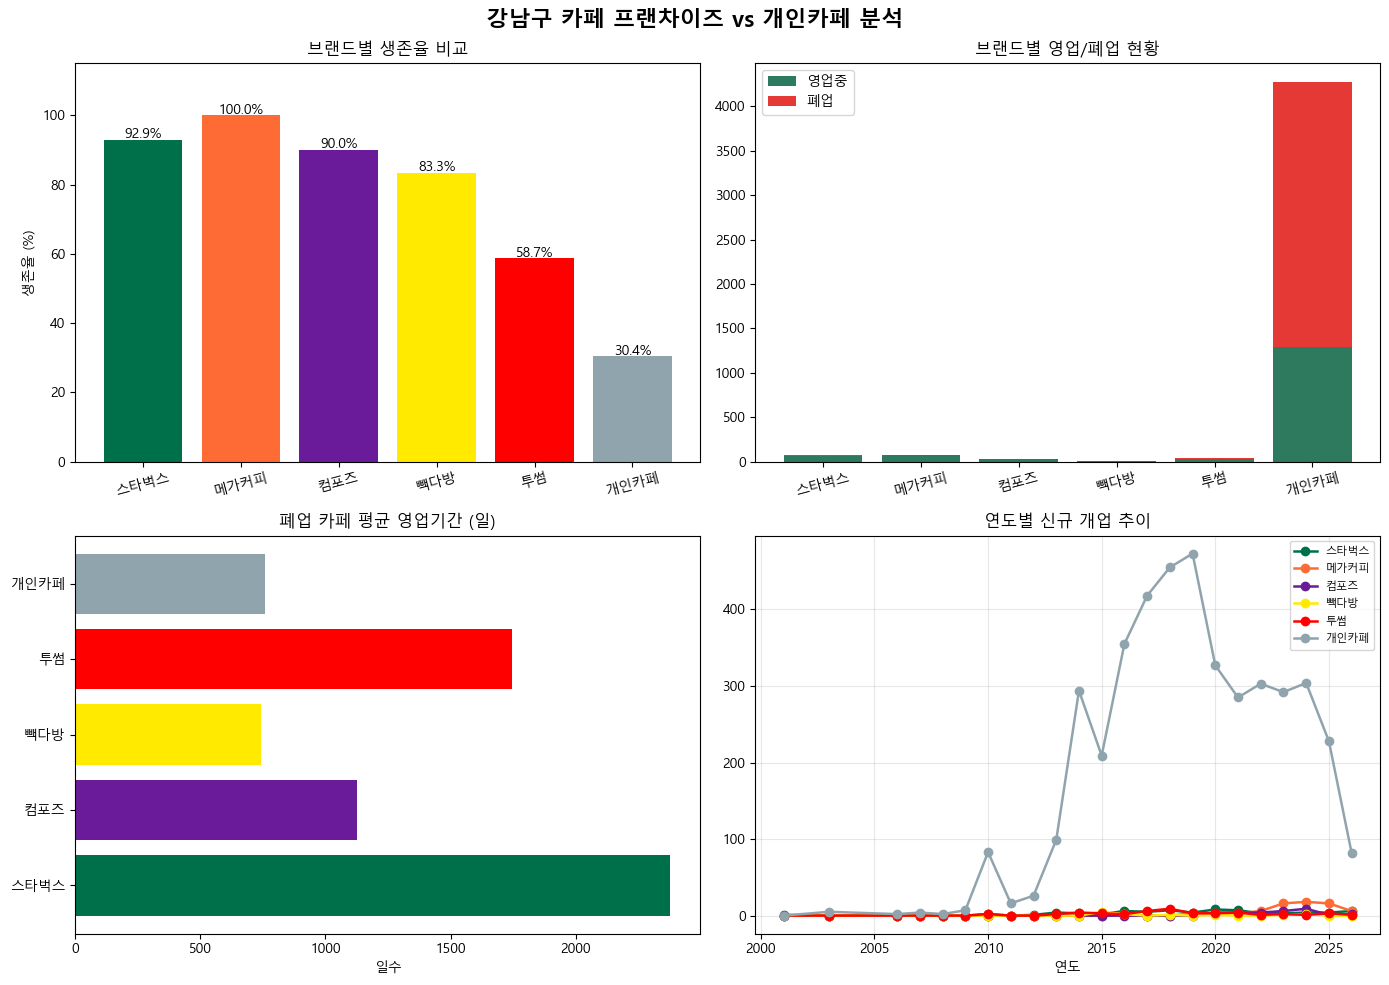

그래프 저장 완료: 강남구_카페_분석.png


In [36]:
colors = {
    '스타벅스': '#00704A',
    '메가커피':  '#FF6B35',
    '컴포즈':   '#6A1B9A',
    '빽다방':   '#FFEA00',
    '투썸':     '#FF0000',
    '개인카페':  '#90A4AE'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('강남구 카페 프랜차이즈 vs 개인카페 분석', fontsize=16, fontweight='bold')

# 그래프 1: 브랜드별 생존율
ax = axes[0][0]
bars = ax.bar(df_result['브랜드'], df_result['생존율(%)'],
              color=[colors[b] for b in df_result['브랜드']])
for bar, val in zip(bars, df_result['생존율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10)
ax.set_title('브랜드별 생존율 비교')
ax.set_ylabel('생존율 (%)')
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=15)

# 그래프 2: 영업 vs 폐업 누적 막대
ax = axes[0][1]
x = range(len(df_result))
ax.bar(x, df_result['영업중'], label='영업중', color='#2D7A5E')
ax.bar(x, df_result['폐업'], label='폐업', color='#E53935',
       bottom=df_result['영업중'])
ax.set_xticks(x)
ax.set_xticklabels(df_result['브랜드'], rotation=15)
ax.set_title('브랜드별 영업/폐업 현황')
ax.legend()

# 그래프 3: 평균 영업 기간
ax = axes[1][0]
df_days = df_result.dropna(subset=['평균영업기간(일)'])
ax.barh(df_days['브랜드'], df_days['평균영업기간(일)'],
        color=[colors[b] for b in df_days['브랜드']])
ax.set_title('폐업 카페 평균 영업기간 (일)')
ax.set_xlabel('일수')

# 그래프 4: 연도별 신규 개업 추이
ax = axes[1][1]
data['개업연도'] = data['인허가일자'].dt.year
yearly = data.groupby(['개업연도', '브랜드']).size().unstack(fill_value=0)
for brand in brands:
    if brand in yearly.columns:
        ax.plot(yearly.index, yearly[brand], marker='o',
                color=colors[brand], label=brand, linewidth=1.8)
ax.set_title('연도별 신규 개업 추이')
ax.set_xlabel('연도')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('강남구_카페_분석.png', dpi=150)
plt.show()
print("그래프 저장 완료: 강남구_카페_분석.png")

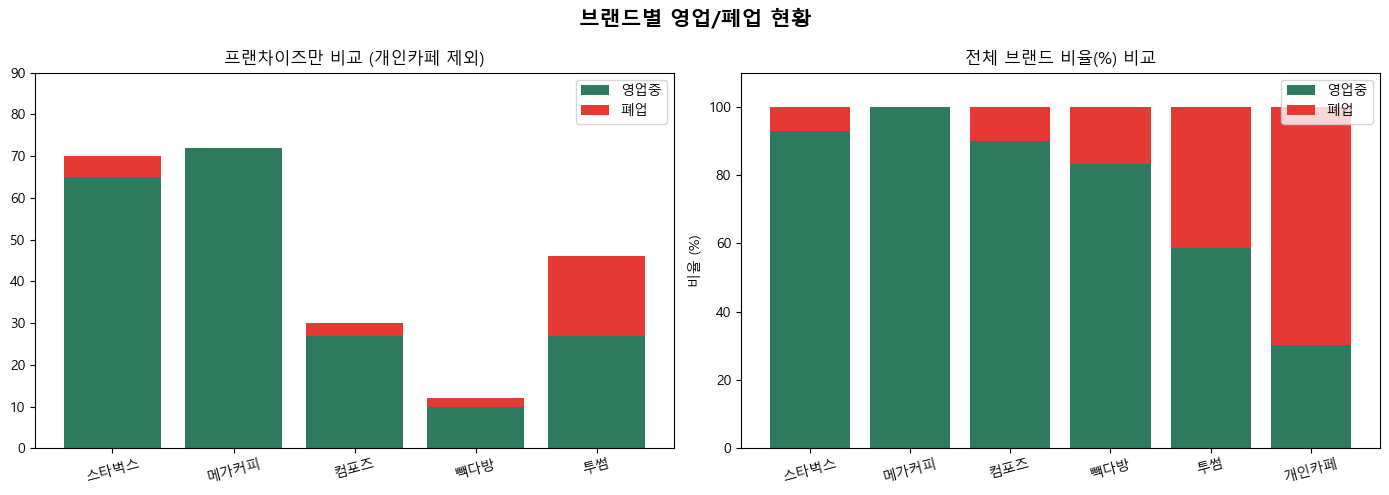

In [37]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

colors = {
    '스타벅스': '#00704A', '메가커피': '#FF6B35',
    '컴포즈': '#6A1B9A', '빽다방': '#FFEA00',
    '투썸': '#FF0000', '개인카페': '#90A4AE'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('브랜드별 영업/폐업 현황', fontsize=15, fontweight='bold')

# ── 그래프 1: 프랜차이즈만 (개인카페 제외) ──
franchise_only = df_result[df_result['브랜드'] != '개인카페']
ax = axes[0]
x = range(len(franchise_only))
ax.bar(x, franchise_only['영업중'], label='영업중', color='#2D7A5E')
ax.bar(x, franchise_only['폐업'], label='폐업', color='#E53935',
       bottom=franchise_only['영업중'].values)
ax.set_xticks(x)
ax.set_xticklabels(franchise_only['브랜드'], rotation=15)
ax.set_ylim(0, 90)  
ax.set_title('프랜차이즈만 비교 (개인카페 제외)')
ax.legend()

# ── 그래프 2: 전체 비율(%) 누적 막대 ──
ax = axes[1]
df_pct = df_result.copy()
df_pct['영업비율'] = df_pct['영업중'] / df_pct['전체'] * 100
df_pct['폐업비율'] = df_pct['폐업']   / df_pct['전체'] * 100

x2 = range(len(df_pct))
ax.bar(x2, df_pct['영업비율'], label='영업중', color='#2D7A5E')
ax.bar(x2, df_pct['폐업비율'], label='폐업', color='#E53935',
       bottom=df_pct['영업비율'].values)
ax.set_xticks(x2)
ax.set_xticklabels(df_pct['브랜드'], rotation=15)
ax.set_ylim(0, 110)
ax.set_ylabel('비율 (%)')
ax.set_title('전체 브랜드 비율(%) 비교')
ax.legend()

plt.tight_layout()
plt.savefig('강남구_영업폐업(개인카페 제외).png', dpi=150)
plt.show()

## 6. 지도 시각화 (folium)

In [38]:
# ✅ 설치 방법 하나로 통일
import sys
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [39]:
import folium
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:5181", "EPSG:4326", always_xy=True)

def tm_to_latlon(x, y):
    lon, lat = transformer.transform(float(x), float(y))
    return lat, lon

# ✅ 공백 문자열까지 걸러내는 필터
map_df = data[
    data['좌표정보(X)'].notna() & data['좌표정보(Y)'].notna() &
    (data['좌표정보(X)'].astype(str).str.strip() != '') &
    (data['좌표정보(Y)'].astype(str).str.strip() != '')
].copy()

lats, lons = [], []
for x, y in zip(map_df['좌표정보(X)'], map_df['좌표정보(Y)']):
    lat, lon = tm_to_latlon(x, y)
    lats.append(lat)
    lons.append(lon)

map_df['위도'] = lats
map_df['경도'] = lons

print(f"지도에 표시할 데이터: {len(map_df)}개")
print(map_df[['사업장명', '위도', '경도']].head(3))

지도에 표시할 데이터: 4497개
            사업장명         위도          경도
0  컴포즈커피 신사세로수길점  37.521731  127.023378
1           카페 융  37.514465  127.028093
2   할리스 강남우리라운지점  37.500394  127.042345


In [48]:
# 강남구 지도 생성
m = folium.Map(location=[37.4979, 127.0276], zoom_start=13)

color_map = {
    '스타벅스': '#00704A',
    '메가커피':  'orange',
    '컴포즈':   'purple',
    '빽다방':   '#FFEA00',
    '투썸':     '#FF0000',
    '개인카페':  'blue'
}

for _, row in map_df.iterrows():
    try:
        brand  = row['브랜드']
        status = row['상세영업상태명']

        # 폐업 가게는 회색으로 표시
        if status == '폐업':
            pin_color = 'lightgray'
        else:
            pin_color = color_map.get(brand, 'gray')

        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=5,
            color=pin_color,
            fill=True,
            fill_color=pin_color,
            fill_opacity=0.8,
            popup=folium.Popup(f"{row['사업장명']} ({status})", max_width=200)
        ).add_to(m)
    except Exception as e:
        continue

# 범례 추가 (HTML)
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index:1000;
     background: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>브랜드 범례</b><br>
  <span style="color:#00704A">●</span> 스타벅스<br>
  <span style="color:orange">●</span> 메가커피<br>
  <span style="color:purple">●</span> 컴포즈<br>
  <span style="color:#FFEA00">●</span> 빽다방<br>
  <span style="color:#FF0000">●</span> 투썸<br>
  <span style="color:blue">●</span> 개인카페<br>
  <span style="color:lightgray">●</span> 폐업 (전 브랜드)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('강남구_카페_지도.html')
print("지도 저장 완료: 강남구_카페_지도.html")

지도 저장 완료: 강남구_카페_지도.html
